## Imports

In [17]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv("data/fragilidade_no_nulls.csv")
print(data.shape)
data.head()

(6705, 64)


,ID_Aluno,Momento,Local_de_Avaliacao,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,Quedas_12meses_Lesao_Sim_Nao,Quedas_12meses_Medo_cair_Sim_Não,...,MMSE_LINGUAGEM_D_LEITURA,MMSE_LINGUAGEM_E_FRASE_ESCRITA,MMSE_COPIA_DESENHO_1,MMSE_Total,EQ5D5L_MOBILIDADE,EQ5D5L_ATIVIDADES_HABITUAIS,EQ5D5L_DOR_MAL_ESTAR,EQ5D5L_ANSIEDADE_DEPRESSAO,EQ5D5L_A_sua_saude_hoje_0_100,Quedas_ultimos_12meses
0,19.0,1.0,1.0,80.0,0.0,1.0,2.0,153.0,1.0,1.0,...,1.0,1.0,0.0,16.0,1.0,1.0,1.0,2.0,80.0,1.0
1,19.0,3.0,1.0,81.0,0.0,1.0,2.0,152.0,1.0,1.0,...,1.0,1.0,0.0,20.0,2.0,2.0,2.0,1.0,80.0,1.0
2,37.0,1.0,1.0,72.0,0.0,1.0,2.0,149.0,0.0,0.0,...,1.0,1.0,0.0,20.0,1.0,1.0,1.0,2.0,100.0,0.0
3,37.0,2.0,1.0,73.0,0.0,1.0,2.0,150.0,0.0,0.0,...,1.0,1.0,1.0,27.0,1.0,1.0,1.0,1.0,100.0,0.0
4,37.0,3.0,1.0,73.0,0.0,1.0,2.0,148.0,0.0,0.0,...,1.0,1.0,0.0,27.0,1.0,1.0,1.0,1.0,70.0,0.0


In [4]:
data.isna().sum()

ID_Aluno                         0
Momento                          0
Local_de_Avaliacao               0
Age                              0
Genero                           0
                                ..
EQ5D5L_ATIVIDADES_HABITUAIS      0
EQ5D5L_DOR_MAL_ESTAR             0
EQ5D5L_ANSIEDADE_DEPRESSAO       0
EQ5D5L_A_sua_saude_hoje_0_100    0
Quedas_ultimos_12meses           0
Length: 64, dtype: int64

## Random Forest

In [5]:
X = data.drop(columns="Quedas_12meses_Medo_cair_Sim_Não")
y = data['Quedas_12meses_Medo_cair_Sim_Não']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.70      0.78      0.74      1104
         1.0       0.69      0.59      0.63       908

    accuracy                           0.69      2012
   macro avg       0.69      0.68      0.69      2012
weighted avg       0.69      0.69      0.69      2012



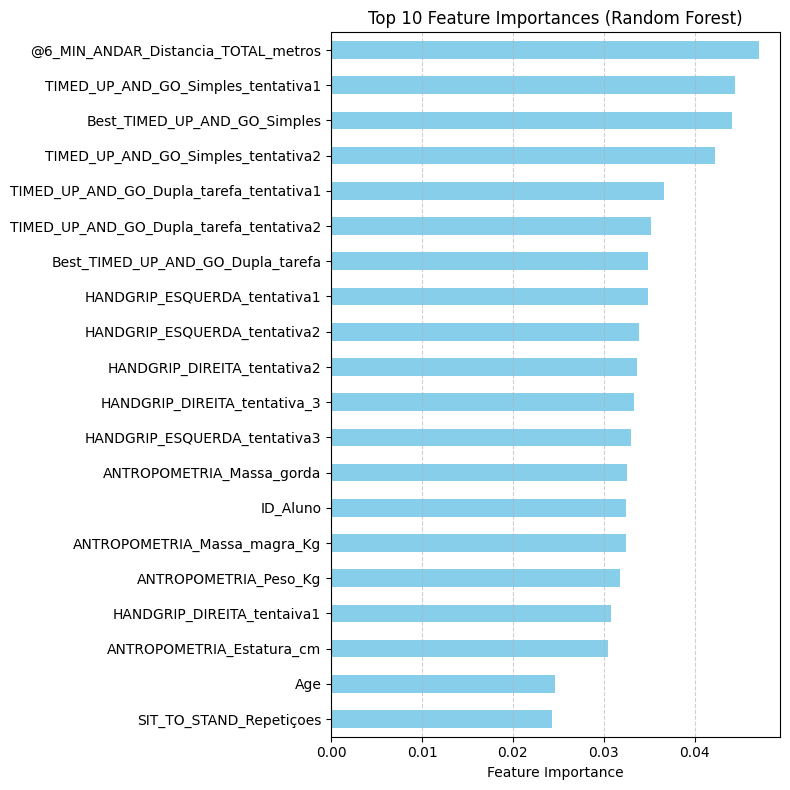

In [6]:
import matplotlib.pyplot as plt

# Get feature importances as a pandas Series for easy sorting
importances = pd.Series(model.feature_importances_, index=X.columns)

# Get top 10 features
top_importances = importances.sort_values(ascending=False).head(20)

# Plot
plt.figure(figsize=(8, 8))
top_importances.plot(kind='barh', color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()  # So the most important is at the top
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


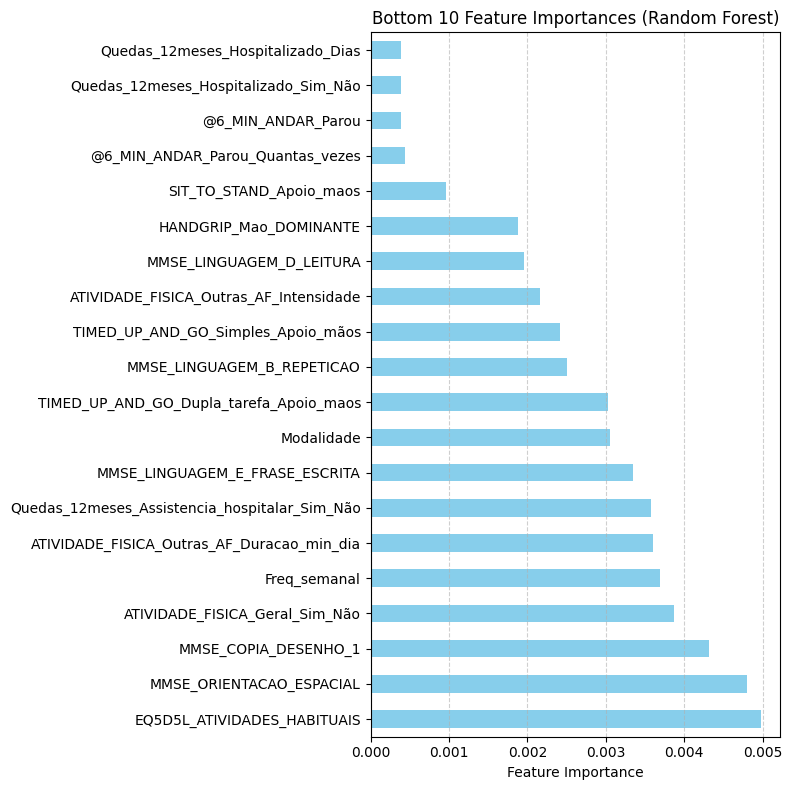

In [7]:
bottom_importances = importances.sort_values(ascending=True).head(20)

# Plot
plt.figure(figsize=(8, 8))
bottom_importances.plot(kind='barh', color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Bottom 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()  # So the most important is at the top
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
importances.sort_values(ascending=False)


@6_MIN_ANDAR_Distancia_TOTAL_metros                  0.047029
TIMED_UP_AND_GO_Simples_tentativa1                   0.044434
Best_TIMED_UP_AND_GO_Simples                         0.044105
TIMED_UP_AND_GO_Simples_tentativa2                   0.042206
TIMED_UP_AND_GO_Dupla_tarefa_tentativa1              0.036613
TIMED_UP_AND_GO_Dupla_tarefa_tentativa2              0.035176
Best_TIMED_UP_AND_GO_Dupla_tarefa                    0.034857
HANDGRIP_ESQUERDA_tentativa1                         0.034849
HANDGRIP_ESQUERDA_tentativa2                         0.033890
HANDGRIP_DIREITA_tentativa2                          0.033618
HANDGRIP_DIREITA_tentativa_3                         0.033329
HANDGRIP_ESQUERDA_tentativa3                         0.032949
ANTROPOMETRIA_Massa_gorda                            0.032495
ID_Aluno                                             0.032447
ANTROPOMETRIA_Massa_magra_Kg                         0.032431
ANTROPOMETRIA_Peso_Kg                                0.031759
HANDGRIP

## Longitudinal Approach

In [10]:
pivoted = data.pivot(index='ID_Aluno', columns='Momento')

# Flatten the multi-index columns
pivoted.columns = [f'{col[0]}_{col[1]}' for col in pivoted.columns]

# Reset index to get PersonID as a column
pivoted = pivoted.reset_index()

In [11]:
pivoted.head()

,ID_Aluno,Local_de_Avaliacao_1.0,Local_de_Avaliacao_2.0,Local_de_Avaliacao_3.0,Local_de_Avaliacao_4.0,Age_1.0,Age_2.0,Age_3.0,Age_4.0,Genero_1.0,Genero_2.0,Genero_3.0,Genero_4.0,Modalidade_1.0,Modalidade_2.0,Modalidade_3.0,Modalidade_4.0,Freq_semanal_1.0,Freq_semanal_2.0,Freq_semanal_3.0,Freq_semanal_4.0,ANTROPOMETRIA_Estatura_cm_1.0,ANTROPOMETRIA_Estatura_cm_2.0,ANTROPOMETRIA_Estatura_cm_3.0,ANTROPOMETRIA_Estatura_cm_4.0,Quedas_12meses_Lesao_Sim_Nao_1.0,Quedas_12meses_Lesao_Sim_Nao_2.0,Quedas_12meses_Lesao_Sim_Nao_3.0,Quedas_12meses_Lesao_Sim_Nao_4.0,Quedas_12meses_Medo_cair_Sim_Não_1.0,Quedas_12meses_Medo_cair_Sim_Não_2.0,Quedas_12meses_Medo_cair_Sim_Não_3.0,Quedas_12meses_Medo_cair_Sim_Não_4.0,ANTROPOMETRIA_Massa_gorda_1.0,ANTROPOMETRIA_Massa_gorda_2.0,ANTROPOMETRIA_Massa_gorda_3.0,ANTROPOMETRIA_Massa_gorda_4.0,ANTROPOMETRIA_Massa_magra_Kg_1.0,ANTROPOMETRIA_Massa_magra_Kg_2.0,ANTROPOMETRIA_Massa_magra_Kg_3.0,ANTROPOMETRIA_Massa_magra_Kg_4.0,HANDGRIP_Mao_DOMINANTE_1.0,HANDGRIP_Mao_DOMINANTE_2.0,HANDGRIP_Mao_DOMINANTE_3.0,HANDGRIP_Mao_DOMINANTE_4.0,HANDGRIP_DIREITA_tentaiva1_1.0,HANDGRIP_DIREITA_tentaiva1_2.0,HANDGRIP_DIREITA_tentaiva1_3.0,HANDGRIP_DIREITA_tentaiva1_4.0,HANDGRIP_DIREITA_tentativa2_1.0,HANDGRIP_DIREITA_tentativa2_2.0,HANDGRIP_DIREITA_tentativa2_3.0,HANDGRIP_DIREITA_tentativa2_4.0,HANDGRIP_ESQUERDA_tentativa1_1.0,HANDGRIP_ESQUERDA_tentativa1_2.0,HANDGRIP_ESQUERDA_tentativa1_3.0,HANDGRIP_ESQUERDA_tentativa1_4.0,HANDGRIP_ESQUERDA_tentativa2_1.0,HANDGRIP_ESQUERDA_tentativa2_2.0,HANDGRIP_ESQUERDA_tentativa2_3.0,HANDGRIP_ESQUERDA_tentativa2_4.0,TIMED_UP_AND_GO_Simples_tentativa1_1.0,TIMED_UP_AND_GO_Simples_tentativa1_2.0,TIMED_UP_AND_GO_Simples_tentativa1_3.0,TIMED_UP_AND_GO_Simples_tentativa1_4.0,TIMED_UP_AND_GO_Simples_tentativa2_1.0,TIMED_UP_AND_GO_Simples_tentativa2_2.0,TIMED_UP_AND_GO_Simples_tentativa2_3.0,TIMED_UP_AND_GO_Simples_tentativa2_4.0,Best_TIMED_UP_AND_GO_Simples_1.0,Best_TIMED_UP_AND_GO_Simples_2.0,Best_TIMED_UP_AND_GO_Simples_3.0,Best_TIMED_UP_AND_GO_Simples_4.0,Percentil_TIMED_UP_AND_GO_Simples_1.0,Percentil_TIMED_UP_AND_GO_Simples_2.0,Percentil_TIMED_UP_AND_GO_Simples_3.0,Percentil_TIMED_UP_AND_GO_Simples_4.0,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1_1.0,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1_2.0,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1_3.0,TIMED_UP_AND_GO_Dupla_tarefa_tentativa1_4.0,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2_1.0,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2_2.0,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2_3.0,TIMED_UP_AND_GO_Dupla_tarefa_tentativa2_4.0,Best_TIMED_UP_AND_GO_Dupla_tarefa_1.0,Best_TIMED_UP_AND_GO_Dupla_tarefa_2.0,Best_TIMED_UP_AND_GO_Dupla_tarefa_3.0,Best_TIMED_UP_AND_GO_Dupla_tarefa_4.0,Percentil_TIMED_UP_AND_GO_Dupla_tarefa_1.0,Percentil_TIMED_UP_AND_GO_Dupla_tarefa_2.0,Percentil_TIMED_UP_AND_GO_Dupla_tarefa_3.0,Percentil_TIMED_UP_AND_GO_Dupla_tarefa_4.0,SIT_TO_STAND_Repetiçoes_1.0,SIT_TO_STAND_Repetiçoes_2.0,SIT_TO_STAND_Repetiçoes_3.0,SIT_TO_STAND_Repetiçoes_4.0,Percentil_SIT_TO_STAND_Repetiçoes_1.0,Percentil_SIT_TO_STAND_Repetiçoes_2.0,Percentil_SIT_TO_STAND_Repetiçoes_3.0,Percentil_SIT_TO_STAND_Repetiçoes_4.0,ANTROPOMETRIA_Peso_Kg_1.0,ANTROPOMETRIA_Peso_Kg_2.0,ANTROPOMETRIA_Peso_Kg_3.0,ANTROPOMETRIA_Peso_Kg_4.0,Escolaridade_1.0,Escolaridade_2.0,Escolaridade_3.0,Escolaridade_4.0,Quedas_12meses_Quantas_1.0,Quedas_12meses_Quantas_2.0,Quedas_12meses_Quantas_3.0,Quedas_12meses_Quantas_4.0,Quedas_12meses_Assistencia_hospitalar_Sim_Não_1.0,Quedas_12meses_Assistencia_hospitalar_Sim_Não_2.0,Quedas_12meses_Assistencia_hospitalar_Sim_Não_3.0,Quedas_12meses_Assistencia_hospitalar_Sim_Não_4.0,Quedas_12meses_Hospitalizado_Sim_Não_1.0,Quedas_12meses_Hospitalizado_Sim_Não_2.0,Quedas_12meses_Hospitalizado_Sim_Não_3.0,Quedas_12meses_Hospitalizado_Sim_Não_4.0,Quedas_12meses_Hospitalizado_Dias_1.0,Quedas_12meses_Hospitalizado_Dias_2.0,Quedas_12meses_Hospitalizado_Dias_3.0,Quedas_12meses_Hospitalizado_Dias_4.0,ATIVIDADE_FISICA_Geral_Sim_Não_1.0,ATIVIDADE_FISICA_Geral_Sim_Não_2.0,ATIVIDADE_FISICA

In [13]:
data.isna().sum()

ID_Aluno                                             0
Momento                                              0
Local_de_Avaliacao                                   0
Age                                                  0
Genero                                               0
Modalidade                                           0
Freq_semanal                                         0
ANTROPOMETRIA_Estatura_cm                            0
Quedas_12meses_Lesao_Sim_Nao                         0
Quedas_12meses_Medo_cair_Sim_Não                     0
ANTROPOMETRIA_Massa_gorda                            0
ANTROPOMETRIA_Massa_magra_Kg                         0
HANDGRIP_Mao_DOMINANTE                               0
HANDGRIP_DIREITA_tentaiva1                           0
HANDGRIP_DIREITA_tentativa2                          0
HANDGRIP_ESQUERDA_tentativa1                         0
HANDGRIP_ESQUERDA_tentativa2                         0
TIMED_UP_AND_GO_Simples_tentativa1                   0
TIMED_UP_A

In [14]:
pivoted.isna().sum()

ID_Aluno                                                    0
Local_de_Avaliacao_1.0                                   1435
Local_de_Avaliacao_2.0                                   1416
Local_de_Avaliacao_3.0                                    890
Local_de_Avaliacao_4.0                                    930
Age_1.0                                                  1435
Age_2.0                                                  1416
Age_3.0                                                   890
Age_4.0                                                   930
Genero_1.0                                               1435
Genero_2.0                                               1416
Genero_3.0                                                890
Genero_4.0                                                930
Modalidade_1.0                                           1435
Modalidade_2.0                                           1416
Modalidade_3.0                                            890
Modalida

In [24]:
def fill_row_nan_with_mode(row):
    if row.isnull().any():
        mode_vals = row.mode(dropna=True)
        if not mode_vals.empty:
            mode_val = mode_vals.iloc[0]  # get first mode if multiple
            return row.fillna(mode_val)
        else:
            # if all values are NaN, just return row as is
            return row
    else:
        return row


In [26]:
targets = ['Quedas_12meses_Medo_cair_Sim_Não_1.0', 'Quedas_12meses_Medo_cair_Sim_Não_2.0', 'Quedas_12meses_Medo_cair_Sim_Não_3.0', 'Quedas_12meses_Medo_cair_Sim_Não_4.0']

X = pivoted.drop(columns=targets)
Y = pivoted[targets]

# Train-test split
X_train, X_test, Y_train, y_test = train_test_split(X, Y, test_size=0.3)

Y_train_filled = Y_train.apply(fill_row_nan_with_mode, axis=1)

# Random Forest model multi output
model = MultiOutputClassifier(RandomForestClassifier())
model.fit(X_train, Y_train_filled)

# Predictions and evaluation
y_pred = model.predict(X_test)

y_test_filled = y_test.apply(fill_row_nan_with_mode, axis=1)
print(classification_report(y_test_filled, y_pred))

              precision    recall  f1-score   support

           0       0.65      0.50      0.56       341
           1       0.65      0.55      0.59       361
           2       0.66      0.59      0.62       391
           3       0.67      0.59      0.63       360

   micro avg       0.66      0.56      0.60      1453
   macro avg       0.66      0.56      0.60      1453
weighted avg       0.66      0.56      0.60      1453
 samples avg       0.31      0.31      0.29      1453

